<a target="_blank" href="https://colab.research.google.com/github/jgromero/dasoc-ap/blob/main/conspiraciones/clasificacion-conspiraciones.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
</a>

# Clasificación de texto

El conjunto de datos utilizado en este ejemplo proviene de la tarea de "Oppositional thinking analysis: Conspiracy theories vs critical thinking narratives" de [PAN 2024](https://pan.webis.de/clef24/pan24-web/oppositional-thinking-analysis.html).

Consiste en una colección de textos extraidos de Telegram anotados manualmente como mensajes "críticos" (`CRITICAL`) frente a "conspirativos" (`CONSPIRACY`).

En este cuaderno se exploran varias aproximaciones a la clasificación de textos usando redes neuronales.


## Carga de datos

Leer datos.

In [3]:
import pandas as pd

data = pd.read_csv('dataset.csv')
data

,text,category
0,THIS IS MASSIVE Australian Senator Malcolm Rob...,CONSPIRACY
1,“ I ’m deeply concerned that the push to vacci...,CRITICAL
2,2021 : They wanted to know your vaccination st...,CRITICAL
3,Anthony Fauci once again defended brutal Chine...,CRITICAL
4,Proof has emerged showing that death from Wuha...,CRITICAL
...,...,...
3995,Police in Australia are warning that unvaccina...,CRITICAL
3996,I personally do n’t believe Putin would set of...,CONSPIRACY
3997,Pfizer lied . We know that . There 's no doubt...,CRITICAL
3998,""" It is utterly bizarre and inexplicable - Dr....",CRITICAL


In [4]:
print(f"An example of CONSPIRACY: {data['text'][0]}")
print(f"An example of CRITICAL: {data['text'][1]}")

An example of CONSPIRACY: THIS IS MASSIVE Australian Senator Malcolm Roberts exposes nanotech found in the Covid ‘ vaccines ’ and says they are genocide . He is the first politician to expose this !   SHARE https :// t . me / LauraAbolichannel 
An example of CRITICAL: “ I ’m deeply concerned that the push to vaccinate these children is nothing more than a dystopian experiment with unknown consequences . ” — Rep. Louie Gohmert ( R - Texas ) # TheDefender https :// childrenshealthdefense . org / defender / fda - eua - covid - shots - infants - young - kids / 


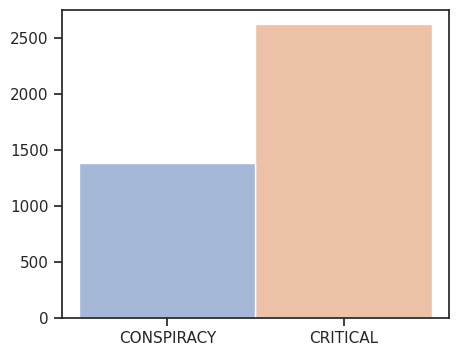

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.set_theme(style="ticks")
sns.histplot(data=data, x='category', hue='category', legend=False)
plt.xlabel('')
plt.ylabel('')
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data['text'], data['category'], test_size=0.2, random_state=42)

Codificar la variable de predicción `category` usando [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html), que por defecto cambia las categorías por números enteros.

In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_numerical = label_encoder.fit_transform(y_train)
y_test_numerical = label_encoder.transform(y_test)

## Clasificación usando índices

### Valores enteros como índices

En primer lugar, creamos una capa de codificación de texto con [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/).

Esta capa tiene opciones básicas para gestionar texto en un modelo de Keras. Por defecto, transforma un conjunto de cadenas en una lista de vectores (`output_mode = "int"`), en la que cada uno de estos vectores es una lista de números enteros correspondientes a los índices de tokens.

- Crear [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/), especificando diversos parámetros.
- Aplicar [`adapt()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization#adapt) para construir el diccionario a partir de datos.

In [8]:
from keras.layers import TextVectorization

vectorizer = TextVectorization(
    max_tokens=20000,
    standardize="lower_and_strip_punctuation",
    output_mode="int",
    output_sequence_length=10)

vectorizer.adapt(X_train)

Podemos recuperar el vocabulario completo construido.

In [9]:
vectorizer.get_vocabulary()[:10]

['', '[UNK]', 'the', 'to', 'of', 'and', 'a', 'in', 'is', 'for']

De esta forma, esta capa puede codificar secuencias de texto. Podemos usarla de forma aislada o dentro de un modelo.

In [10]:
input_data = [
    ["Covid adviser Fauci gets revoked security protection"],
    ["A COVID-19 vaccine was developed by Pfizer"]
]
vectorizer(input_data)

<tf.Tensor: shape=(2, 10), dtype=int64, numpy=
array([[  13, 4629,  235, 1133, 8583, 1340, 1157,    0,    0,    0],
       [   6,  871,   12,   40, 1292,   26,   86,    0,    0,    0]])>

Usando la capa de [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/), podemos crear y entrenar un modelo de clasificación.

In [11]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense

vectorizer = TextVectorization(
    max_tokens=20000,
    output_sequence_length=100)
vectorizer.adapt(X_train)

model_indices = Sequential([
    vectorizer,
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

In [12]:
model_indices.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_indices.fit(
    tf.convert_to_tensor(X_train),
    y_train_numerical,
    epochs=50,
    validation_split=0.2)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5534 - loss: 655.3770 - val_accuracy: 0.6156 - val_loss: 360.5229
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6376 - loss: 244.7128 - val_accuracy: 0.5938 - val_loss: 287.9999
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6600 - loss: 154.9620 - val_accuracy: 0.5766 - val_loss: 261.3945
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6645 - loss: 129.8663 - val_accuracy: 0.6078 - val_loss: 228.3398
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6898 - loss: 98.2718 - val_accuracy: 0.5906 - val_loss: 226.2207
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7302 - loss: 71.8744 - val_accuracy: 0.5703 - val_loss: 206.3958
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7469 - loss: 58.2802 - val_accuracy: 0.5594 - val_loss: 204.7352
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7747 - loss: 42.1693 - val_ac

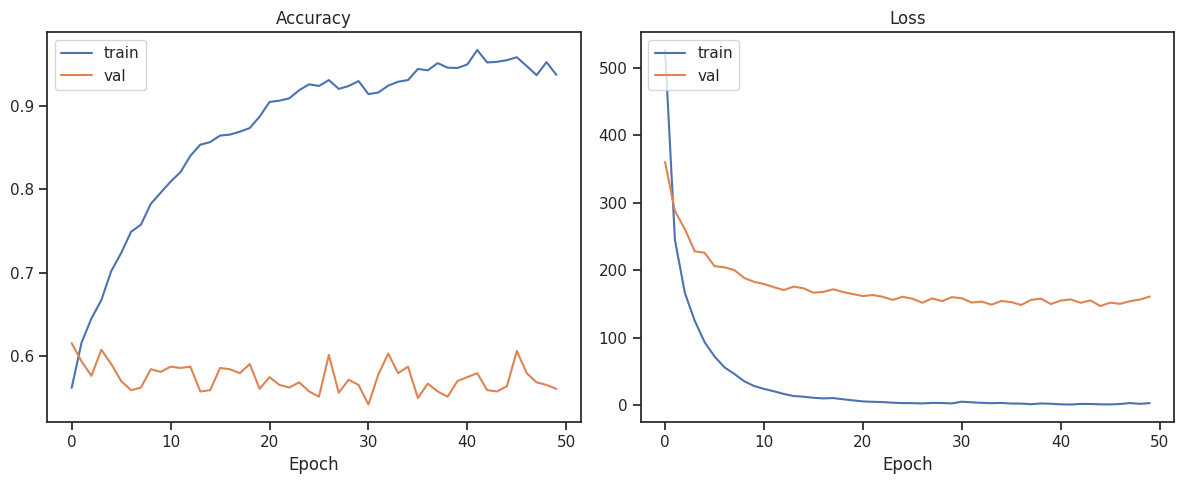

In [13]:
# Creamos una función para crear las gráficas que reutilizaremos en adelante
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='train')
    ax1.plot(history.history['val_accuracy'], label='val')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(loc='upper left')

    # Loss
    ax2.plot(history.history['loss'], label='train')
    ax2.plot(history.history['val_loss'], label='val')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

plot_training_history(history)

### Codificaciones one-hot y tf-idf

Podemos utilizar otro tipo de codificaciones con la misma capa [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/); por ejemplo, one-hot o tf-idf.

In [14]:
# Ejemplo de codificación tipo one-hot
vectorizer = TextVectorization(
    max_tokens=20000,
    output_mode="multi_hot")
vectorizer.adapt(X_train)

input_data = [
    ["Covid adviser Fauci gets revoked security protection"],
    ["A COVID-19 vaccine was developed by Pfizer"]
]
vectorizer(input_data)
pd.DataFrame(vectorizer(input_data).numpy(), columns=vectorizer.get_vocabulary())

,[UNK],the,to,of,and,a,in,is,for,that,...,2816,2814,2800000,280,27s,2796427,2794886,2791253,2780342438778873,27793
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Y entrenar un modelo de clasificación de la forma habitual.

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7353 - loss: 0.5687 - val_accuracy: 0.8641 - val_loss: 0.3598
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9445 - loss: 0.1815 - val_accuracy: 0.8703 - val_loss: 0.3473
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9891 - loss: 0.0784 - val_accuracy: 0.8719 - val_loss: 0.3695
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9988 - loss: 0.0338 - val_accuracy: 0.8672 - val_loss: 0.3952
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9990 - loss: 0.0186 - val_accuracy: 0.8656 - val_loss: 0.4204
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9998 - loss: 0.0114 - val_accuracy: 0.8687 - val_loss: 0.4571
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9993 - loss: 0.0085 - val_accuracy: 0.8594 - val_loss: 0.4639
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 0.0046 - val_accuracy: 0.8672 - val_los

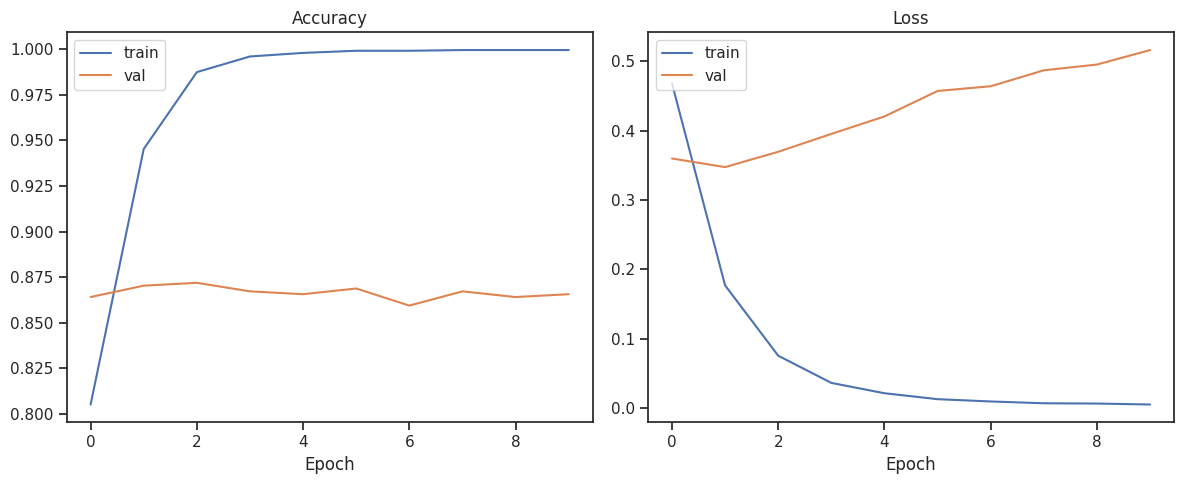

In [15]:
# Modelo one-hot
model_onehot = Sequential([
    vectorizer,
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model_onehot.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_onehot.fit(
    tf.convert_to_tensor(X_train),
    y_train_numerical,
    epochs=10,
    validation_split=0.2)

plot_training_history(history)

In [16]:
# Ejemplo de codificación tipo tf-idf
vectorizer = TextVectorization(
    max_tokens=20000,
    output_mode="tf-idf")
vectorizer.adapt(X_train)

input_data = [
    ["Covid adviser Fauci gets revoked security protection"],
    ["A COVID-19 vaccine was developed by Pfizer"]
]
vectorizer(input_data)
pd.DataFrame(vectorizer(input_data).numpy(), columns=vectorizer.get_vocabulary())

,[UNK],the,to,of,and,a,in,is,for,that,...,2816,2814,2800000,280,27s,2796427,2794886,2791253,2780342438778873,27793
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.019169,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7024 - loss: 0.5521 - val_accuracy: 0.8562 - val_loss: 0.4286
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9789 - loss: 0.0916 - val_accuracy: 0.8438 - val_loss: 0.4802
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9980 - loss: 0.0278 - val_accuracy: 0.8562 - val_loss: 0.5533
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9987 - loss: 0.0111 - val_accuracy: 0.8516 - val_loss: 0.5932
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9992 - loss: 0.0064 - val_accuracy: 0.8562 - val_loss: 0.6428
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9985 - loss: 0.0052 - val_accuracy: 0.8562 - val_loss: 0.7054
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9998 - loss: 0.0042 - val_accuracy: 0.8547 - val_loss: 0.6770
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9983 - loss: 0.0083 - val_accuracy: 0.8516 - val_lo

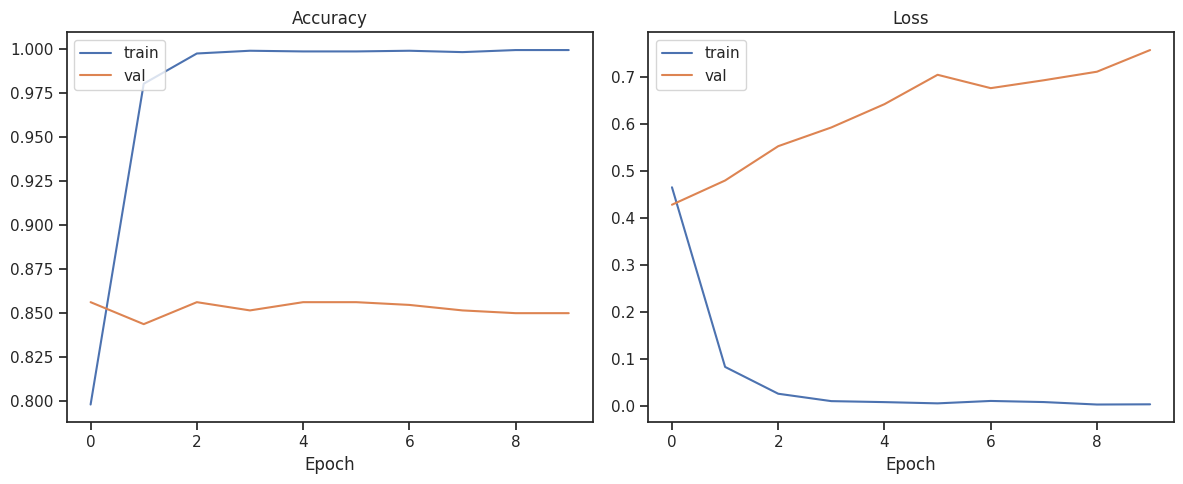

In [17]:
# Modelo tf-idf
model_tfidf = Sequential([
    vectorizer,
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model_tfidf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_tfidf.fit(
    tf.convert_to_tensor(X_train),
    y_train_numerical,
    epochs=10,
    validation_split=0.2)

plot_training_history(history)

## Clasificación usando _embeddings_

### Entrenando una capa de _embeddings_

Podemos utilizar una capa de [`Embedding`](https://keras.io/api/layers/core_layers/embedding/) para que la red aprenda una representación de los tokens optimizada para este problema.



Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6778 - loss: 0.6157 - val_accuracy: 0.8141 - val_loss: 0.4213
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9419 - loss: 0.1531 - val_accuracy: 0.8219 - val_loss: 0.4015
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9990 - loss: 0.0070 - val_accuracy: 0.8297 - val_loss: 0.4226
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9993 - loss: 0.0017 - val_accuracy: 0.8359 - val_loss: 0.4339
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9999 - loss: 0.0014 - val_accuracy: 0.8328 - val_loss: 0.4419


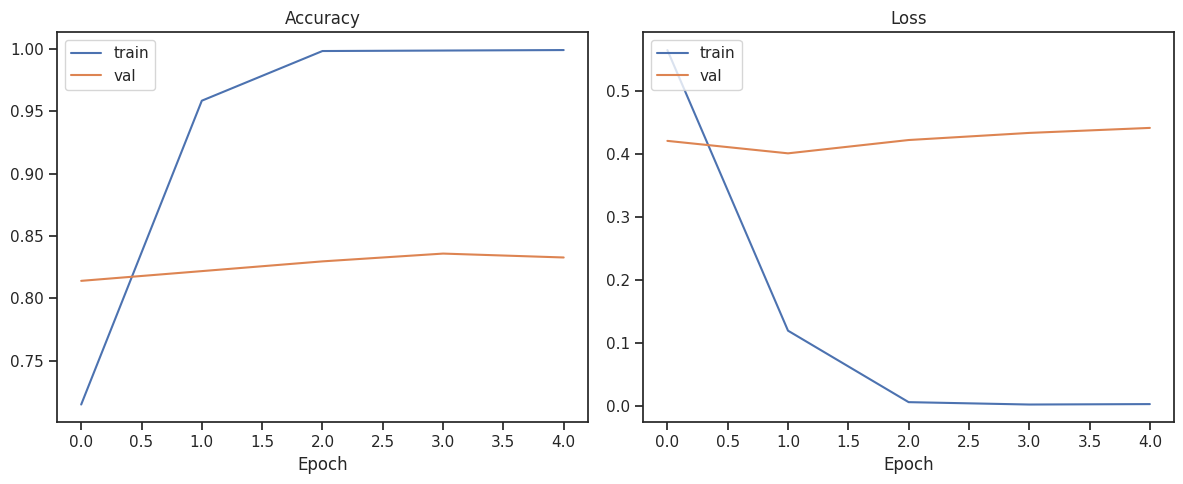

In [18]:
from keras.layers import Embedding, Flatten, Input
from keras.models import Model

max_length = 100
max_tokens = 20000

vectorizer = TextVectorization(
  max_tokens=max_tokens,
  output_mode="int",
  output_sequence_length=max_length,
)
vectorizer.adapt(X_train)

model_embedding = Sequential([
    Embedding(input_dim=max_tokens, output_dim=256),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_embedding.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

X_train_numerical = vectorizer(tf.convert_to_tensor(X_train))
history = model_embedding.fit(
    X_train_numerical,
    y_train_numerical,
    epochs=5,
    validation_split=0.2
)

plot_training_history(history)

### Usando _embeddings_ precalculados

El proceso anterior es lento. En lugar de entrenar nuestra propia capa [`Embedding`](https://keras.io/api/layers/core_layers/embedding/), podemos usar _embeddings_ preentrenados, como por ejemplo [Glove](https://nlp.stanford.edu/projects/glove/). Para ello, necesitamos:

* Preparar el `vectorizer`
* Descargar Glove
* Preparar los valores descargados para insertarlos como pesos en la capa [`Embedding`](https://keras.io/api/layers/core_layers/embedding/)
  * Crear diccionario token -> embedding
  * Crear matriz de embeddings
* Crear el modelo especificando estos pesos
* Entrenar el modelo

In [19]:
# Preparar el vectorizer
vectorizer = TextVectorization(
  max_tokens=max_tokens,
  output_mode="int",
  output_sequence_length=max_length,
)

vectorizer.adapt(X_train)

In [20]:
# Descargar GloVe
import os
import urllib.request
import zipfile

glove_url  = "http://nlp.stanford.edu/data/glove.6B.zip"
glove_path = "glove.6B.zip"
glove_dir  = "glove"

if not os.path.exists(glove_path):
    print("Downloading GloVe embeddings...")
    urllib.request.urlretrieve(glove_url, glove_path)

# Extraer fichero
if not os.path.exists(glove_dir):
    print("Extracting GloVe embeddings...")
    with zipfile.ZipFile(glove_path, "r") as zip_ref:
        zip_ref.extractall(glove_dir)

print("GloVe embeddings are ready!")

Extracting GloVe embeddings...
GloVe embeddings are ready!


In [21]:
import numpy as np
from tqdm import tqdm

# Crear diccionario de embeddings, mostrando las 5 primeras líneas del fichero
embedding_index = {}
with open('glove/glove.6B.100d.txt', encoding='utf-8') as f:

    # Contar número de líneas y mostrar las 5 primeras
    num_lines = 0
    for i, line in enumerate(f):
        if i < 5:
            print(line.strip())
        num_lines += 1
    f.seek(0)

    # Crear diccionario token -> embedding
    for i, line in enumerate(tqdm(f, desc="Reading GloVe file", total=num_lines)):
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

# Crear la matriz de embeddings
embedding_dim = 100
vocab_size = len(vectorizer.get_vocabulary())
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for i, word in enumerate(tqdm(vectorizer.get_vocabulary(), desc="Processing vocabulary")):
    embedding_vector = embedding_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

the -0.038194 -0.24487 0.72812 -0.39961 0.083172 0.043953 -0.39141 0.3344 -0.57545 0.087459 0.28787 -0.06731 0.30906 -0.26384 -0.13231 -0.20757 0.33395 -0.33848 -0.31743 -0.48336 0.1464 -0.37304 0.34577 0.052041 0.44946 -0.46971 0.02628 -0.54155 -0.15518 -0.14107 -0.039722 0.28277 0.14393 0.23464 -0.31021 0.086173 0.20397 0.52624 0.17164 -0.082378 -0.71787 -0.41531 0.20335 -0.12763 0.41367 0.55187 0.57908 -0.33477 -0.36559 -0.54857 -0.062892 0.26584 0.30205 0.99775 -0.80481 -3.0243 0.01254 -0.36942 2.2167 0.72201 -0.24978 0.92136 0.034514 0.46745 1.1079 -0.19358 -0.074575 0.23353 -0.052062 -0.22044 0.057162 -0.15806 -0.30798 -0.41625 0.37972 0.15006 -0.53212 -0.2055 -1.2526 0.071624 0.70565 0.49744 -0.42063 0.26148 -1.538 -0.30223 -0.073438 -0.28312 0.37104 -0.25217 0.016215 -0.017099 -0.38984 0.87424 -0.72569 -0.51058 -0.52028 -0.1459 0.8278 0.27062
, -0.10767 0.11053 0.59812 -0.54361 0.67396 0.10663 0.038867 0.35481 0.06351 -0.094189 0.15786 -0.81665 0.14172 0.21939 0.58505 -0.52158 

Processing vocabulary: 100%|██████████| 20000/20000 [00:00<00:00, 439638.38it/s]


In [22]:
# Construir el modelo usando la matriz de embeddings
model_glove = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], trainable=False),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_glove.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6643 - loss: 0.6628 - val_accuracy: 0.7234 - val_loss: 0.5333
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8672 - loss: 0.3253 - val_accuracy: 0.7531 - val_loss: 0.5164
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9617 - loss: 0.1439 - val_accuracy: 0.7531 - val_loss: 0.5682
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9877 - loss: 0.0670 - val_accuracy: 0.7312 - val_loss: 0.6621
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9992 - loss: 0.0306 - val_accuracy: 0.7375 - val_loss: 0.7239


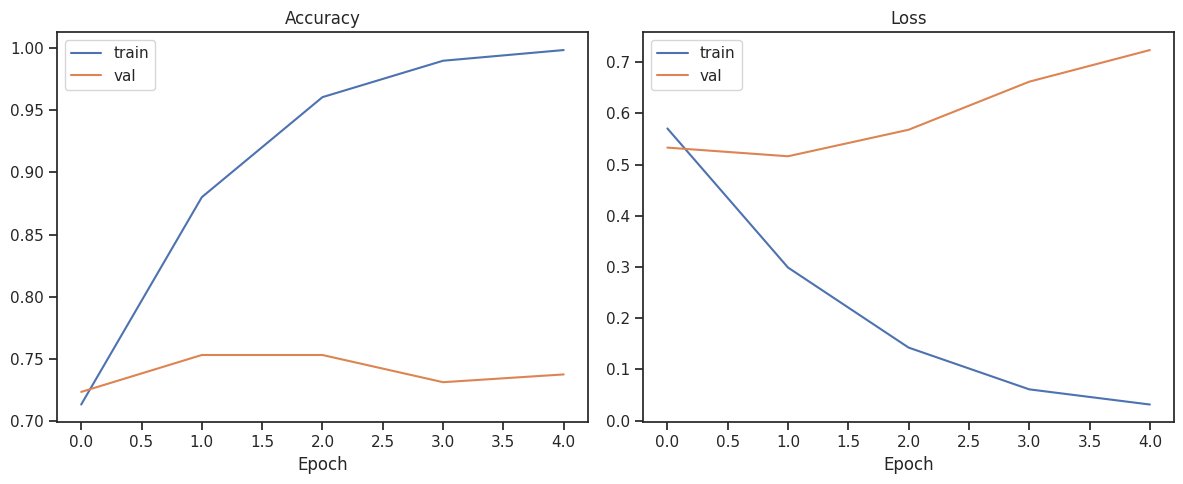

In [23]:
# Entrenar el modelo
X_train_numerical = vectorizer(tf.convert_to_tensor(X_train))
history = model_glove.fit(
    X_train_numerical,
    y_train_numerical,
    epochs=5,
    validation_split=0.2
)

plot_training_history(history)

### Usando _embeddings_ procedentes de un modelo de lenguaje
Los modelos de lenguaje actuales suelen incluir una sección de generación de _embeddings_. Muchos de estos modelos ofrecen la posibilidad de consultar el _embedding_ para una un token o para una frase completa.

En este ejemplo, usamos [`SentenceTransformer`](https://sbert.net/), de la biblioteca [`sentence_transformers`](https://sbert.net/), para generar los _embeddings_. Esta aproximación es más sencilla que la anterior para GloVe, ya que disponemos de utilidades para interactuar con los modelos.

In [24]:
from sentence_transformers import SentenceTransformer

# Cargar el modelo preentrenado
transformer = SentenceTransformer('all-MiniLM-L6-v2')

# Generar embeddings para los datos de entrenamiento
X_train_embeddings = transformer.encode(X_train.tolist())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

En este caso es especialmente interesante visualizar los _embeddings_. Para ello, reducimos la dimensionalidad a 2 usando [UMAP](https://umap-learn.readthedocs.io/en/latest/) y dibujamos en dos dimensiones.

In [25]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_train_2d = reducer.fit_transform(X_train_embeddings)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


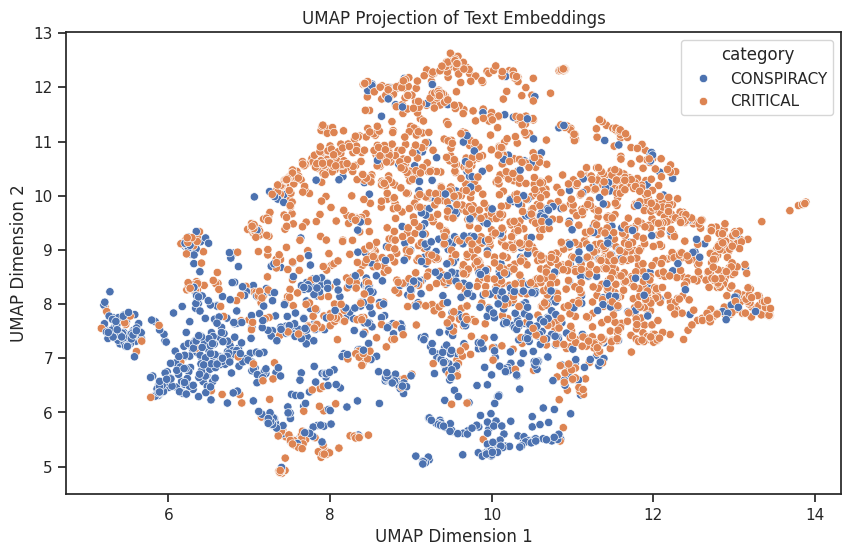

In [26]:
import seaborn as sns

df_embeddings = pd.DataFrame(X_train_2d, columns=['UMAP Dimension 1', 'UMAP Dimension 2'])
df_embeddings['category'] = y_train.tolist()

plt.figure(figsize=(10, 6))
sns.set_theme(style="ticks")
sns.scatterplot(x='UMAP Dimension 1', y='UMAP Dimension 2', hue='category', data=df_embeddings)
plt.title('UMAP Projection of Text Embeddings')
plt.show()

Finalmente, con los _embeddings_ obtenidos podemos entrenar un nuevo modelo.

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7006 - loss: 0.6021 - val_accuracy: 0.8047 - val_loss: 0.4541
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8139 - loss: 0.4227 - val_accuracy: 0.8234 - val_loss: 0.3845
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8269 - loss: 0.3746 - val_accuracy: 0.8281 - val_loss: 0.3740
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8508 - loss: 0.3470 - val_accuracy: 0.8484 - val_loss: 0.3514
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8638 - loss: 0.3199 - val_accuracy: 0.8516 - val_loss: 0.3433
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8722 - loss: 0.3125 - val_accuracy: 0.8578 - val_loss: 0.3390
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8720 - loss: 0.3019 - val_accuracy: 0.8625 - val_loss: 0.3384
Epoch 8/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8822 - loss: 0.2885 - val_accuracy: 0.8641 - val_loss:

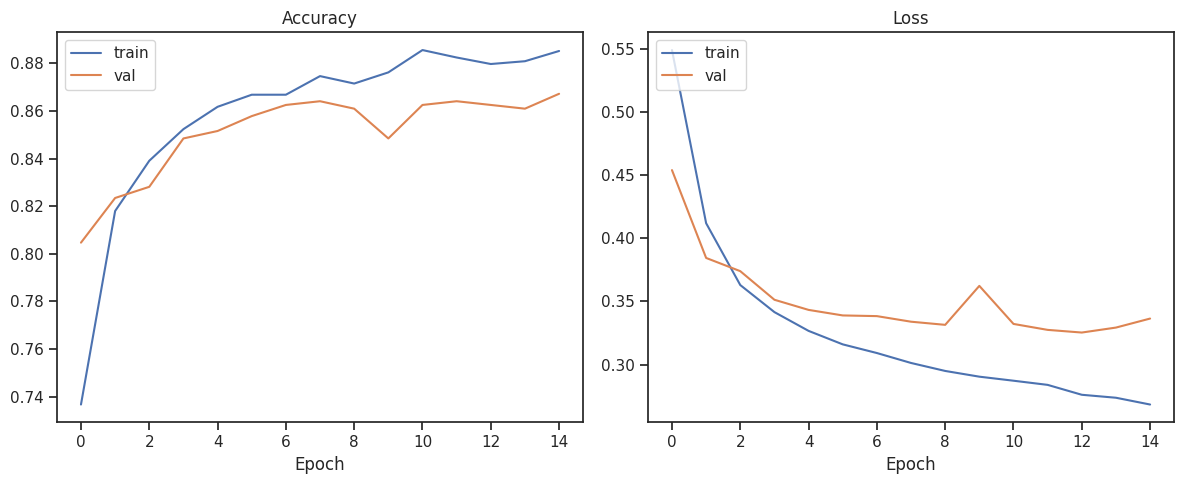

In [27]:
model_transformer = Sequential([
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model_transformer.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_transformer.fit(
    X_train_embeddings,
    y_train_numerical,
    epochs=15,
    validation_split=0.2)

plot_training_history(history)